In [1]:
%pip install -q numpy pandas seaborn scikit-learn xgboost joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


1.Import libraries

In [2]:
#importing the required libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,class_likelihood_ratios,recall_score,precision_score,f1_score


In [3]:
#configurations
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)


Path=r"C:\Users\swath\Desktop\Projects_MLDL\Capstone_projects\Multi-disease-predictor\dataset\diabetes.csv"
target_col="Outcome"

2.Load data

In [4]:
df=pd.read_csv(Path)
print("Diabetes shape:",df.shape)
df.head()

Diabetes shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


3.EDA

Target:
0:Non diabetes
1: Diabetes

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


8 numeric columns and 0 categorical columns

In [6]:
#missing values
df.isnull().sum().sort_values()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
#values counts for columns

for col in df.columns:
    print(f"Value counts for column: {col}")
    print(df[col].value_counts().head(10))
    print("\n")

Value counts for column: Pregnancies
Pregnancies
1    135
0    111
2    103
3     75
4     68
5     57
6     50
7     45
8     38
9     28
Name: count, dtype: int64


Value counts for column: Glucose
Glucose
100    17
99     17
125    14
111    14
106    14
129    14
102    13
105    13
95     13
112    13
Name: count, dtype: int64


Value counts for column: BloodPressure
BloodPressure
70    57
74    52
78    45
68    45
72    44
64    43
80    40
76    39
60    37
0     35
Name: count, dtype: int64


Value counts for column: SkinThickness
SkinThickness
0     227
32     31
30     27
27     23
23     22
33     20
18     20
28     20
31     19
19     18
Name: count, dtype: int64


Value counts for column: Insulin
Insulin
0      374
105     11
140      9
130      9
120      8
94       7
100      7
180      7
115      6
110      6
Name: count, dtype: int64


Value counts for column: BMI
BMI
32.0    13
31.6    12
31.2    12
0.0     11
32.4    10
33.3    10
30.1     9
32.9     9
32.8     9
3

In [8]:
#value counts of target column

df[target_col].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Note: There is some imbalance, so we will pay attention to recall/f1 and use class weighting

Inference: Some columns have missing values encoded as 0

In [9]:
#identify columns with zero values
zero_value_cols=[col for col in df.columns if (df[col]==0).sum()>0 and col!=target_col]
print("Columns with zero values:",zero_value_cols)


Columns with zero values: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [10]:
#counts of zero values in each column
for col in zero_value_cols:
    zero_count=(df[col]==0).sum()
    print(f"Column: {col}, Zero values count: {zero_count}")

Column: Pregnancies, Zero values count: 111
Column: Glucose, Zero values count: 5
Column: BloodPressure, Zero values count: 35
Column: SkinThickness, Zero values count: 227
Column: Insulin, Zero values count: 374
Column: BMI, Zero values count: 11


Note: In this dataset Pregnancies can legitimately have a value of 0 while 0 in glucose, Bloodpressure,Skinthinckness, insulin and BMI is physiologically invalid and therefore represents missing data. These values need to be imputed with meanmedian values

In [11]:
#duplicate

duplicate_data=df.duplicated()
num_duplicates=duplicate_data.sum()
num_duplicates

np.int64(0)

In [12]:
#imbalance_ratio
n_diab=(df[target_col]==1).sum()
n_non_dia=(df[target_col]==0).sum()
print("Imabalance ratio (Non diabetes:Diabetes)",round(n_non_dia/max(n_diab,1),2))

Imabalance ratio (Non diabetes:Diabetes) 1.87


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


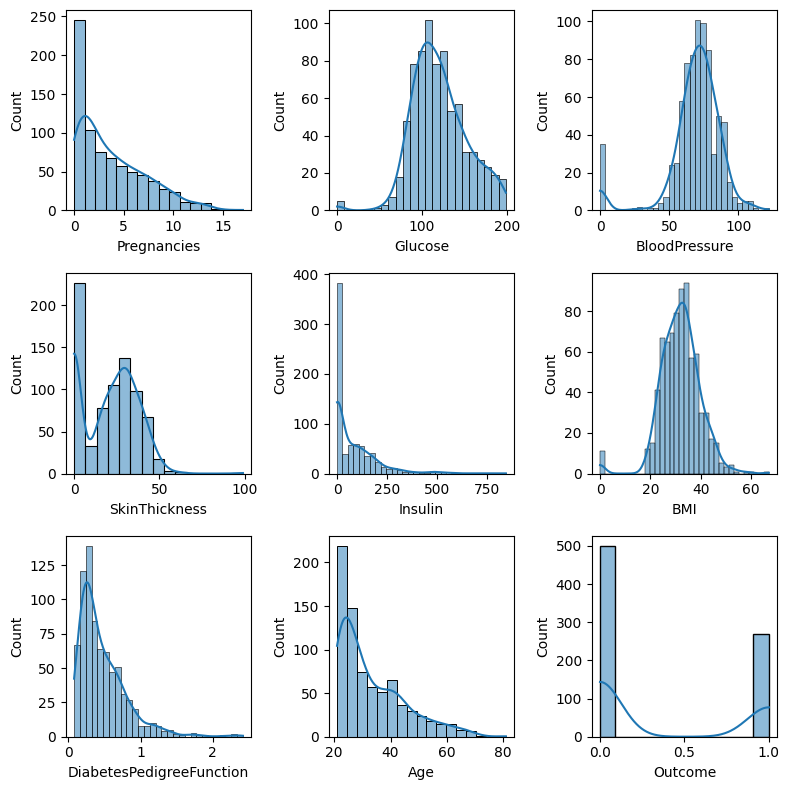

In [14]:
#histplot
plt.figure(figsize=(8,8))
for i,col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde=True)
plt.tight_layout()    
plt.show()

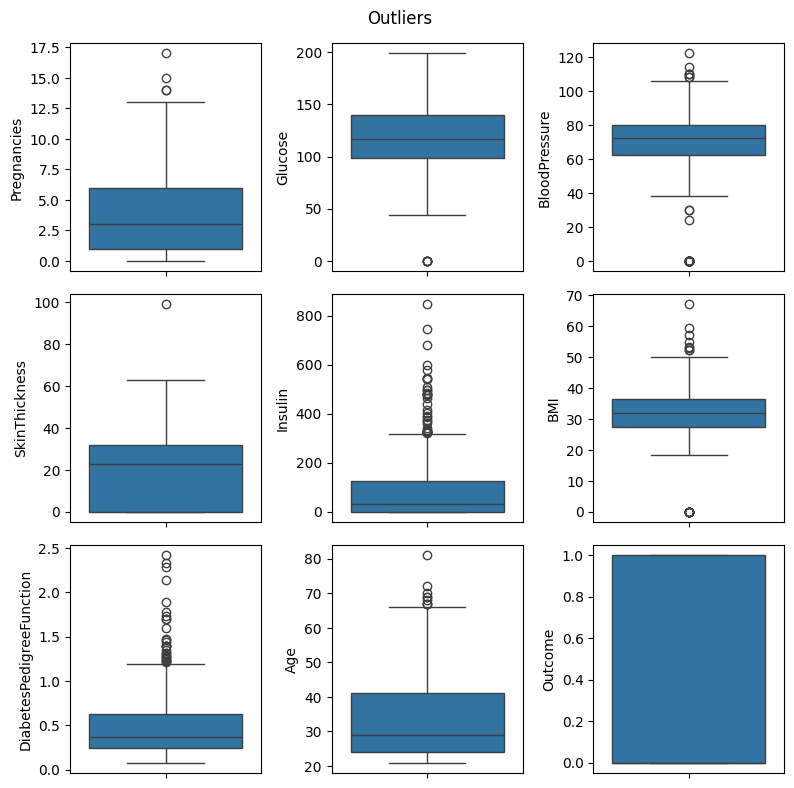

In [15]:
#histplot
plt.figure(figsize=(8,8))
plt.suptitle("Outliers")

for i,col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(df[col])
plt.tight_layout()    
plt.show()

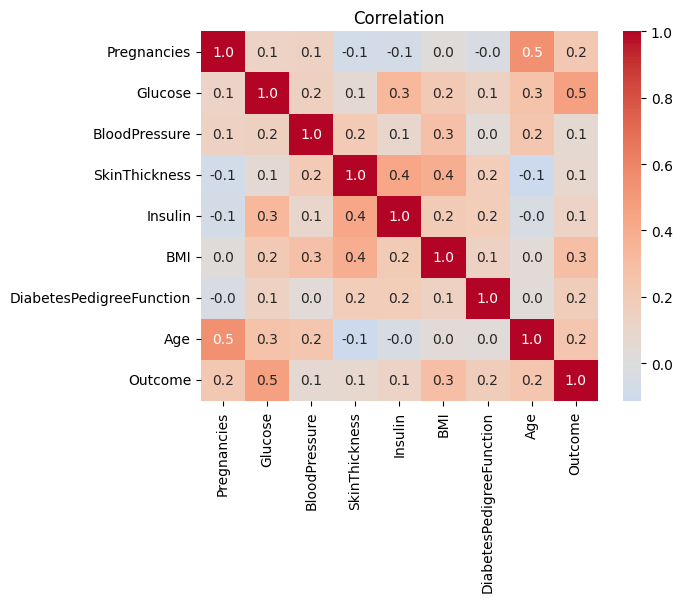

In [16]:
#correlation

plt.title("Correlation")
sns.heatmap(df.corr(),annot=True,fmt=".1f",center=0,cmap="coolwarm")
plt.show()

In [17]:
#separating x and y

x=df.drop(target_col,axis=1)
y=df[target_col]

In [18]:
#train test split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [19]:
print("datset shape:",df.shape)
print("x_train shape:",x_train.shape)
print("y_train shape:",y_train.shape)
print("x_test shape:",x_test.shape)
print("y_test shape:",y_test.shape)

datset shape: (768, 9)
x_train shape: (614, 8)
y_train shape: (614,)
x_test shape: (154, 8)
y_test shape: (154,)


Preprocessing Pipeline

In [20]:
zero_value_cols

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [21]:
#0 -> NAN for selected columns: NAN --> median imputation

zero_as_missing_cols=zero_value_cols
#we can remove pregnancies from as here
zero_as_missing_cols.remove("Pregnancies")
zero_as_missing_cols

['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [22]:
numeric_features=df.select_dtypes(include=[np.number]).columns.to_list()
numeric_features.remove("Outcome")
numeric_features

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [23]:
# #transformer to replace 0--> NAN for selected columns

# zer0_to_nan=FunctionTransformer(
#     lambda x:x.assign(**{col:x[col].replace(0,np.nan) for col in zero_as_missing_cols}),
#     validation=False
# )

def replace_zeros_with_nan_df(x,cols):
    
    """
    replace 0-> NAN for selected columns in a pandas dataframe.
    Returns a NEW dataframe (safe for sklearn pipelines).
    """
    
    x=x.copy()
    for col in cols:
        if col in x.columns:
            x[col]=x[col].replace(0,np.nan)
    return x 

zero_to_nan=FunctionTransformer(
    replace_zeros_with_nan_df,
    kw_args={"cols":zero_as_missing_cols},
    validate=False
)


numerical_transformer=Pipeline(
    steps=[
        ("zero_to_nan",zero_to_nan),
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)


preprocess=ColumnTransformer(
    transformers=[
        ("num",numerical_transformer,numeric_features)
    ]
)

Baseline model-logistic regression

In [24]:
#baseline model with preprocessing

basline_lr=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",LogisticRegression())
    ]
)

In [25]:
#training teh pipeline
basline_lr.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

In [26]:
#reusable evaluation function

def evaluate_classifier(model,x_train,y_train,x_test,y_test,model_name):
    #prediction
    train_pred=model.predict(x_train)
    test_pred=model.predict(x_test)
    
    #accuracy
    train_acc=accuracy_score(y_train,train_pred)*100
    test_acc=accuracy_score(y_test,test_pred)*100
    
    #results
    print(f"{model_name}-Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name}-Test Accuracy: {test_acc:.2f}%")
    
    print("-"*40)
    
    print("Train Classification report")
    print(classification_report(y_train,train_pred))
    
    print("-"*40)
    
    print("Test Classification report")
    print(classification_report(y_test,test_pred))

In [27]:
evaluate_classifier(
basline_lr,x_train,y_train,x_test,y_test,"Baseline Logistic regression"
)

Baseline Logistic regression-Train Accuracy: 79.64%
Baseline Logistic regression-Test Accuracy: 70.78%
----------------------------------------
Train Classification report
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614

----------------------------------------
Test Classification report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [28]:
#models to try

models={
    "LogisticRegression":Pipeline(
        [
            ("preprocess",preprocess),
            ("model",LogisticRegression(random_state=42,class_weight="balanced",max_iter=1000))
        ]
    ),
    "SVM":Pipeline(
        [
            ("preprocess",preprocess),
            ("model",SVC(random_state=42,class_weight="balanced"))
        ]
    ),
    "RandomClassifier":Pipeline(
        [
            ("preprocess",preprocess),
            ("model",RandomForestClassifier(random_state=42,class_weight="balanced"))
        ]
    ),
    "XGBoostclassifier":Pipeline(
        [
            ("preprocess",preprocess),
            ("model",XGBClassifier(eval_metric="logloss"))
        ]
    )
}

In [29]:
k=5
cv=StratifiedKFold(n_splits=k,shuffle=True,random_state=42)

In [30]:
for name,model_pipeline in models.items():
    
    recall_scores=[]
    f1_scores=[]
    
    for tr_idx,te_idx in cv.split(x_train,y_train):
        x_tr,x_te=x_train.iloc[tr_idx],x_train.iloc[te_idx]
        y_tr,y_te=y_train.iloc[tr_idx],y_train.iloc[te_idx]
        
        model_pipeline.fit(x_tr,y_tr)
        pred=model_pipeline.predict(x_te)
        
        recall_scores.append(round(recall_score(y_te, pred), 2))
        f1_scores.append(round(f1_score(y_te, pred), 2))
        
    print("Model name",name)
    print("Recall values:",recall_scores)
    print("F1 score:",f1_scores)
    print("\n CV recall mean",round(float(np.mean(recall_scores)),4))
    print("\n CV recall mean",round(float(np.mean(recall_scores)),4))
    print("*"*53)

Model name LogisticRegression
Recall values: [0.7, 0.74, 0.63, 0.72, 0.71]
F1 score: [0.69, 0.67, 0.65, 0.68, 0.67]

 CV recall mean 0.7

 CV recall mean 0.7
*****************************************************
Model name SVM
Recall values: [0.77, 0.84, 0.67, 0.77, 0.76]
F1 score: [0.74, 0.69, 0.69, 0.67, 0.66]

 CV recall mean 0.762

 CV recall mean 0.762
*****************************************************
Model name RandomClassifier
Recall values: [0.7, 0.72, 0.7, 0.72, 0.69]
F1 score: [0.7, 0.69, 0.71, 0.64, 0.67]

 CV recall mean 0.706

 CV recall mean 0.706
*****************************************************
Model name XGBoostclassifier
Recall values: [0.53, 0.6, 0.6, 0.58, 0.62]
F1 score: [0.6, 0.63, 0.63, 0.56, 0.62]

 CV recall mean 0.586

 CV recall mean 0.586
*****************************************************


Note: SVM (SUPPORT VECTOR CLASSIFIER) has better performance

In [31]:
svc_opt=Pipeline([
    ("preprocess",preprocess),
    ("model",SVC(
        class_weight="balanced",random_state=42
    ))
])

In [36]:
# param_combination

param_grid={
    "model__C":[0.1,1,10,100,1000],
    "model__gamma":[0.001,0.01,0.1,1,"scale"]
}

In [37]:
#grid search

grid_search=GridSearchCV(
    estimator=svc_opt,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    verbose=True,
    n_jobs=-1
)

In [38]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid

In [39]:
print("Hyperparameter tuning results")
print("Best parameters:",grid_search.best_params_)
print("Best CV F1 score:",round(grid_search.best_score_,4))

Hyperparameter tuning results
Best parameters: {'model__C': 1, 'model__gamma': 'scale'}
Best CV F1 score: 0.6902


Retrain with best Params

In [40]:
svc_best=Pipeline([
    ("preproess",preprocess),
    ("model",SVC(
        random_state=42,
        class_weight="balanced",
        C=grid_search.best_params_["model__C"],
        gamma=grid_search.best_params_["model__gamma"]
    ))
])

In [41]:
svc_best.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preproess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [42]:
evaluate_classifier(
    svc_best,x_train,y_train,x_test,y_test,"SVM with best hyperparameters"
)

SVM with best hyperparameters-Train Accuracy: 82.25%
SVM with best hyperparameters-Test Accuracy: 72.73%
----------------------------------------
Train Classification report
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       400
           1       0.70      0.85      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.83       614

----------------------------------------
Test Classification report
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



Predictive model

In [47]:
def predictive_model(input_features):
    input_df=pd.DataFrame(input_features,columns=x_train.columns)
    
    prediction=svc_best.predict(input_df)
    print("Model prediction:",prediction[0])
    if prediction[0]==1:
        print("Diabetic")
    else:
        print("Non diabetic")

In [48]:
predictive_model([[5,116,74,0,0,25.6,0.201,30]])

Model prediction: 0
Non diabetic
